### Importing the Libraries

In [6]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
import sklearn 
from sklearn import datasets
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score
from sklearn.tree import DecisionTreeClassifier , plot_tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix

### Load the Dataset

In [8]:
data1 = pd.read_csv("Car Price dataset.csv")

### Info of the Data 

In [10]:
data1.info

<bound method DataFrame.info of     Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0       ritz  2014           3.35           5.59       27000    Petrol   
1        sx4  2013           4.75           9.54       43000    Diesel   
2       ciaz  2017           7.25           9.85        6900    Petrol   
3    wagon r  2011           2.85           4.15        5200    Petrol   
4      swift  2014           4.60           6.87       42450    Diesel   
..       ...   ...            ...            ...         ...       ...   
296     city  2016           9.50          11.60       33988    Diesel   
297     brio  2015           4.00           5.90       60000    Petrol   
298     city  2009           3.35          11.00       87934    Petrol   
299     city  2017          11.50          12.50        9000    Diesel   
300     brio  2016           5.30           5.90        5464    Petrol   

    Seller_Type Transmission  Owner  
0        Dealer       Manual      0  
1  

In [11]:
data1

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


### Checking the null values in the dataset

In [13]:
data1.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

### we apply one-hot encoding to the entire feature dataset. This converts all categorical variables into numerical (0/1) format.

In [15]:
data1 = pd.get_dummies(data1, columns=["Car_Name", "Fuel_Type", "Seller_Type", "Transmission"], drop_first=True, dtype=int)

In [16]:
data1

,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Name_Activa 3g,Car_Name_Activa 4g,Car_Name_Bajaj ct 100,Car_Name_Bajaj Avenger 150,Car_Name_Bajaj Avenger 150 street,...,Car_Name_swift,Car_Name_sx4,Car_Name_verna,Car_Name_vitara brezza,Car_Name_wagon r,Car_Name_xcent,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,2014,3.35,5.59,27000,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
1,2013,4.75,9.54,43000,0,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,1
2,2017,7.25,9.85,6900,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
3,2011,2.85,4.15,5200,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,1
4,2014,4.60,6.87,42450,0,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,2016,9.50,11.60,33988,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
297,2015,4.00,5.90,60000,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
298,2009,3.35,11.00,87934,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
299,2017,11.50,12.50,9000,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1


### y contains the Targets of the dataset 

In [18]:
y = data1["Selling_Price"]

### In x, we are first removing the target from the dataset. So, after removing the it x will contain all the features of the dataset

In [20]:
x = data1.drop("Selling_Price",axis=1)

### Target

In [22]:
y

0       3.35
1       4.75
2       7.25
3       2.85
4       4.60
       ...  
296     9.50
297     4.00
298     3.35
299    11.50
300     5.30
Name: Selling_Price, Length: 301, dtype: float64

### Feature 

In [24]:
x

,Year,Present_Price,Kms_Driven,Owner,Car_Name_Activa 3g,Car_Name_Activa 4g,Car_Name_Bajaj ct 100,Car_Name_Bajaj Avenger 150,Car_Name_Bajaj Avenger 150 street,Car_Name_Bajaj Avenger 220,...,Car_Name_swift,Car_Name_sx4,Car_Name_verna,Car_Name_vitara brezza,Car_Name_wagon r,Car_Name_xcent,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,2014,5.59,27000,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
1,2013,9.54,43000,0,0,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,1
2,2017,9.85,6900,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
3,2011,4.15,5200,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,1
4,2014,6.87,42450,0,0,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,2016,11.60,33988,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
297,2015,5.90,60000,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
298,2009,11.00,87934,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
299,2017,12.50,9000,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1


### Now, we apply feature scaling using StandardScaler to normalize the input features.

In [26]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

### The dataset is split into training (80%) and testing (20%) sets. The training set is used to train the model, while the testing set is used to evaluate its performance with Predicted data of the Model.

In [28]:
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state = 42)

# Linear Regression

### Creating the model 

In [31]:
model_lr = LinearRegression()

### Training the model 

In [33]:
model_lr.fit(x_train, y_train)

LinearRegression()

### y_pred_lr contains the predicate value of the model which has been got after training the model with x_test

In [35]:
y_pred_lr = model_lr.predict(x_test)
y_pred_lr

array([-3.75451528e+13,  9.58715820e+00,  5.49389648e+00, -4.03564453e-01,
        8.55493164e+00,  6.87622070e+00,  1.47387695e+00,  4.36931752e+13,
        8.67431641e-01,  6.67651367e+00,  1.34649690e+13,  2.92236328e-01,
        7.95996094e+00,  7.84651588e+13,  6.11743164e+00,  2.69433594e+00,
        2.67309570e+00,  1.09858398e+01,  2.15250533e+14,  1.73698765e+14,
        2.42081856e+14,  7.62060547e+00,  5.57250977e+00,  1.88647461e+00,
        5.78093067e+13,  3.48754883e+00,  5.47436523e+00,  1.58569336e+00,
        2.67871094e+00,  2.66918945e+00,  7.64160156e-02,  9.11987305e+00,
       -2.39965820e+00,  1.98608398e+00,  8.35278320e+00,  3.98559570e+00,
        6.08520508e+00,  6.16821289e+00,  4.27709961e+00,  6.74096680e+00,
        5.49438477e+00, -2.59470961e+14,  3.66772461e+00,  2.93457031e-01,
       -5.01464360e+13,  1.30126953e-01,  8.34228516e+00,  9.55175781e+00,
        3.87524414e+00,  4.03906250e+00,  5.84130859e+00,  2.69824219e+00,
        2.29387207e+01,  

### y_test contains the actual values of the dataset 

In [37]:
y_test

177     0.35
289    10.11
228     4.95
198     0.15
60      6.95
       ...  
234     5.50
296     9.50
281     2.10
285     7.40
182     0.30
Name: Selling_Price, Length: 61, dtype: float64

### EVALUTION METRICS OF LINEAR REGRESSION 

In [39]:
print("EVALUATION METRICS OF LINEAR REGRESSION")
print("Mean Absolute Error = ",mean_absolute_error(y_test, y_pred_lr))
print("Mean Square Error = ",mean_squared_error(y_test, y_pred_lr))
print("r2 Score = ",r2_score(y_test, y_pred_lr))

EVALUATION METRICS OF LINEAR REGRESSION
Mean Absolute Error =  19206988753783.65
Mean Square Error =  3.572889464413445e+27
r2 Score =  -1.551030520309292e+26


# Desision Tree

### Creating the Model 

In [42]:
model_dt = DecisionTreeRegressor(random_state = 42)

### Training the Model with x_train and y_train

In [44]:
model_dt.fit(x_train,y_train)

DecisionTreeRegressor(random_state=42)

### y_test contains the predicated values which has been gotten after training the model by with x_test

In [46]:
y_pred_dt = model_dt.predict(x_test)
y_pred_dt

array([ 0.5 ,  9.15,  4.5 ,  0.16,  7.05,  6.75,  1.11,  0.5 ,  0.48,
        7.25,  7.25,  1.25,  7.5 ,  0.45,  5.95,  2.55,  1.25, 14.25,
        0.48,  1.45,  0.25,  8.75,  4.5 ,  2.7 ,  0.45,  2.9 ,  5.25,
        2.95,  1.15,  1.11,  0.25,  8.55,  0.45,  2.25,  7.75,  3.9 ,
        5.85,  7.45,  2.55,  7.05,  3.49,  2.25,  5.8 ,  0.6 ,  6.75,
        0.65,  8.5 ,  4.  ,  3.1 ,  3.1 ,  4.8 ,  1.65, 19.99, 20.75,
        6.45,  9.15,  5.25,  8.99,  3.25,  6.4 ,  0.25])

### y_test contains the Actual values of the Dataset

In [48]:
y_test

177     0.35
289    10.11
228     4.95
198     0.15
60      6.95
       ...  
234     5.50
296     9.50
281     2.10
285     7.40
182     0.30
Name: Selling_Price, Length: 61, dtype: float64

### EVALUATION METRICS OF DECISION TREE

In [50]:
print("EVALUATION METRICS OF DECISION TREE")
print("Mean Absolute Error : " ,mean_absolute_error(y_test, y_pred_dt))
print("Mean Square Error = ",mean_squared_error(y_test, y_pred_dt))
print("R2 Score = ",r2_score(y_test, y_pred_dt))

EVALUATION METRICS OF DECISION TREE
Mean Absolute Error :  0.6655737704918032
Mean Square Error =  1.1880950819672134
R2 Score =  0.948423488845238


# Random Forest

### Creating the Model 

In [53]:
model_rf = RandomForestRegressor(random_state = 42)

### Training the Model 

In [55]:
model_rf.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

### y_pred_rf contains the predicated values of the model which have been got after training the model with x_test

In [57]:
y_pred_rf = model_rf.predict(x_test)
print(y_pred_rf)

[ 0.4289 10.2911  4.957   0.209   7.5213  6.5595  1.124   0.588   0.4606
  6.8085  7.9837  1.104   8.1953  0.4576  5.35    2.613   1.134  14.3729
  0.4661  1.5545  0.3174  7.7989  4.7745  2.7115  0.5104  3.4895  5.256
  3.212   1.1826  1.1713  0.3943  8.9435  0.4643  2.555   8.044   4.01
  6.4743  5.9761  2.5945  6.4727  4.6626  3.7122  4.744   0.5577  6.1615
  0.7144  8.204   6.7485  2.9765  3.538   4.986   1.511  22.9945 20.8486
  6.46   10.2833  5.145   8.8027  2.9115  6.6114  0.2228]


### y_test contains Actual Values of the Dataset 

In [59]:
y_test

177     0.35
289    10.11
228     4.95
198     0.15
60      6.95
       ...  
234     5.50
296     9.50
281     2.10
285     7.40
182     0.30
Name: Selling_Price, Length: 61, dtype: float64

### EVALUTION METRICES OF RANDOM FOREST

In [61]:
print("EVALUATION METRICES OF RANDOM FOREST ")
print("Mean Absolute Error = ",mean_absolute_error(y_test, y_pred_rf))
print("Mean Square Error = ",mean_squared_error(y_test, y_pred_rf))
print("R2 Score = ",r2_score(y_test, y_pred_rf))

EVALUATION METRICES OF RANDOM FOREST 
Mean Absolute Error =  0.5881016393442622
Mean Square Error =  0.7658002888524589
R2 Score =  0.9667557691805942


# Conclusion

In this, different machine learning regression models were used to predict car selling prices based on various features such as present price, kilometers driven, fuel type, transmission, and car age. Among all the models, the Random Forest Regressor performed the best with the highest R² score and lowest prediction error, showing excellent accuracy in predicting car prices. Decision Tree Regressor also gave strong results, while Linear Regression performed poorly due to limitations in handling the dataset relationships. Overall, this project demonstrates how machine learning can effectively predict car prices using historical vehicle data.

### Correlation Heatmap

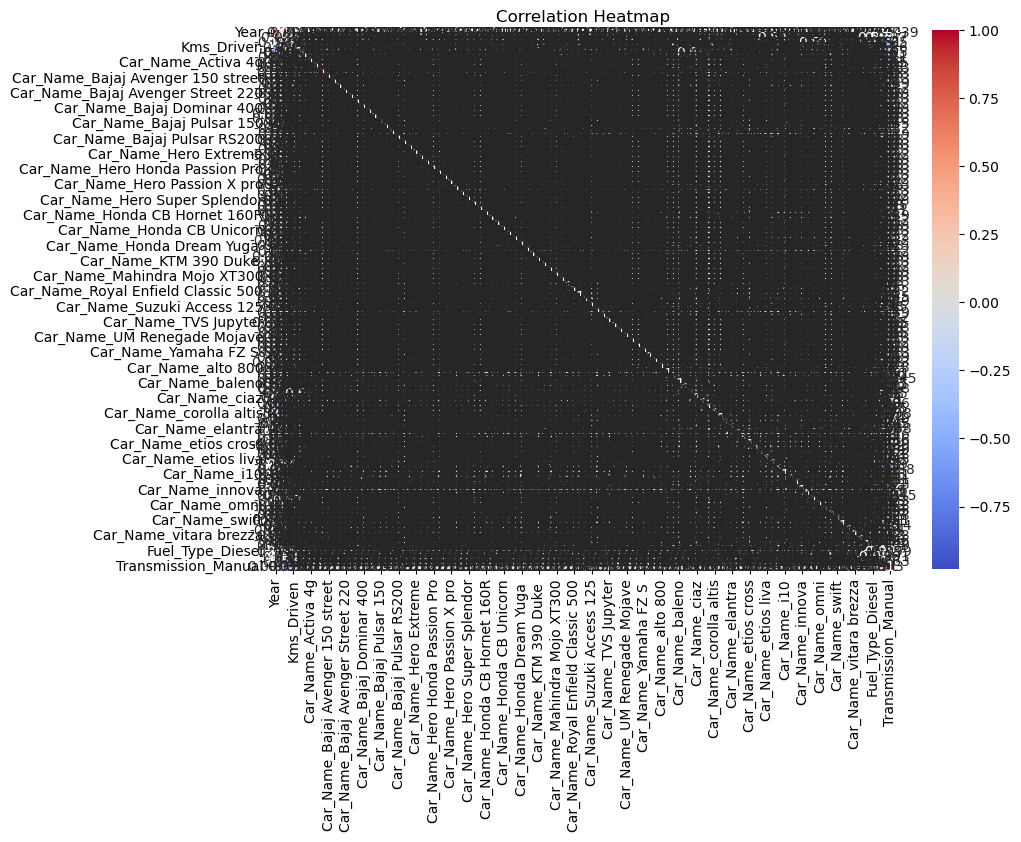

In [65]:
plt.figure(figsize=(10,7))
sns.heatmap(data1.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Present Price vs Selling Price of the Given Dataset

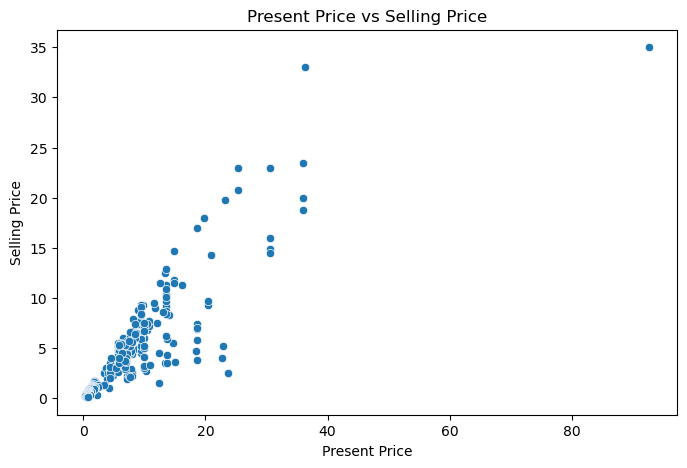

In [67]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=data1['Present_Price'],y=data1['Selling_Price'])
plt.title("Present Price vs Selling Price")
plt.xlabel("Present Price")
plt.ylabel("Selling Price")
plt.show()

### Actual vs Predicted Prices of Random forest model 

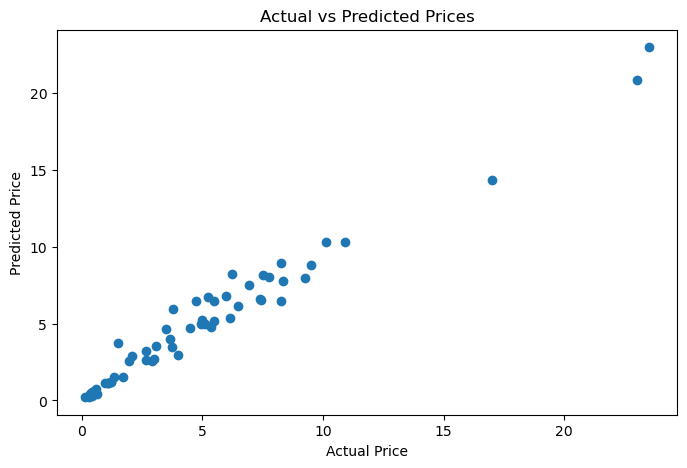

In [69]:
# Chart of Actual Price vs Predicted Price which have gotten from random Forest 
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.show()